## Country Development Clustering — Analysis Report

---

### Objective

The objective of this analysis is to classify countries across the world into meaningful development groups using unsupervised machine learning techniques. By leveraging socio-economic and health indicators such as child mortality, GDP per capita, income, life expectancy, and fertility rate, the goal is to uncover hidden patterns that distinguish developed, developing, and underdeveloped nations, and to validate those groupings using supervised classification models.

---

### Problem Statement

Across 167 countries, vast disparities exist in healthcare, economic output, and quality of life. International organizations such as UNICEF, WHO, and the World Bank need data-driven frameworks to identify which countries require urgent aid and intervention. However, with multiple correlated socio-economic indicators, it is difficult to manually segment countries into actionable groups.

**This analysis addresses the following questions:**

- Can unsupervised clustering (K-Means, DBSCAN) identify meaningful country groupings from raw socio-economic data?
- Which features most strongly drive the separation between developed and underdeveloped nations?
- Can supervised models (Random Forest, XGBoost) validate and replicate the cluster structure with high accuracy?
- Which countries should be prioritized for humanitarian aid based on their cluster profile?

---

### Conclusion

This analysis successfully segmented 167 countries into **three distinct development tiers** using K-Means clustering on nine socio-economic and health indicators.

**Key findings:**

| Cluster | Label | Countries | Key Characteristic |
|---|---|---|---|
| **0** | Developed | ~36 | High income, low child mortality, long life expectancy |
| **1** | Underdeveloped | ~47 | High child mortality, low GDP, high fertility |
| **2** | Developing | ~84 | Middle ground improving but lagging behind |

- **Child mortality, GDP per capita, and total fertility rate** emerged as the three most influential features driving cluster separation, collectively accounting for over 60% of Random Forest feature importance.
- **Random Forest achieved 100% accuracy** and **XGBoost achieved 97.06% accuracy** in replicating the cluster labels, confirming that the K-Means segmentation is statistically robust and not arbitrary.
- **DBSCAN** identified 30 outlier nations extreme economies like Qatar and Luxembourg, or severely fragile states  that do not fit neatly into the three-tier structure.
- Countries in **Cluster 1** represent the most urgent humanitarian concern and should be prioritized for international aid, healthcare investment, and sustainable development programs.

> The analysis demonstrates that a small set of well-chosen indicators is sufficient to meaningfully stratify global development  providing a reproducible, data-driven foundation for policy decisions and resource allocation.

## 1) Download libraries

In [21]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost


[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Import libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file 

In [23]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [24]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) columns

This dataset contains socio-economic and health indicators for 167 countries and is commonly used for country development clustering:
- **country** — Name of the country
- **child_mort** — Deaths of children under 5 years per 1000 live births
- **exports** — Exports of goods and services (% of GDP per capita)
- **health** — Total health spending (% of GDP per capita)
- **imports** — Imports of goods and services (% of GDP per capita)
- **income** — Net income per person (USD)
- **inflation** — Annual growth rate of the total GDP (%)
- **life_expec** — Average life expectancy at birth (years)
- **total_fer** — Average number of children per woman
- **gdpp** — GDP per capita (USD)

In [25]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [26]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

**Observations — Basic Cleaning:**
- The dataset contains **167 rows and 10 columns** with no missing values, so no imputation was actually required.
- Column names were lowercased and stripped for consistency.
- No duplicate rows were found after calling `drop_duplicates()`.
- All 9 numeric features are clean and ready for scaling and clustering.

## 7) Exploratory Data Analysis

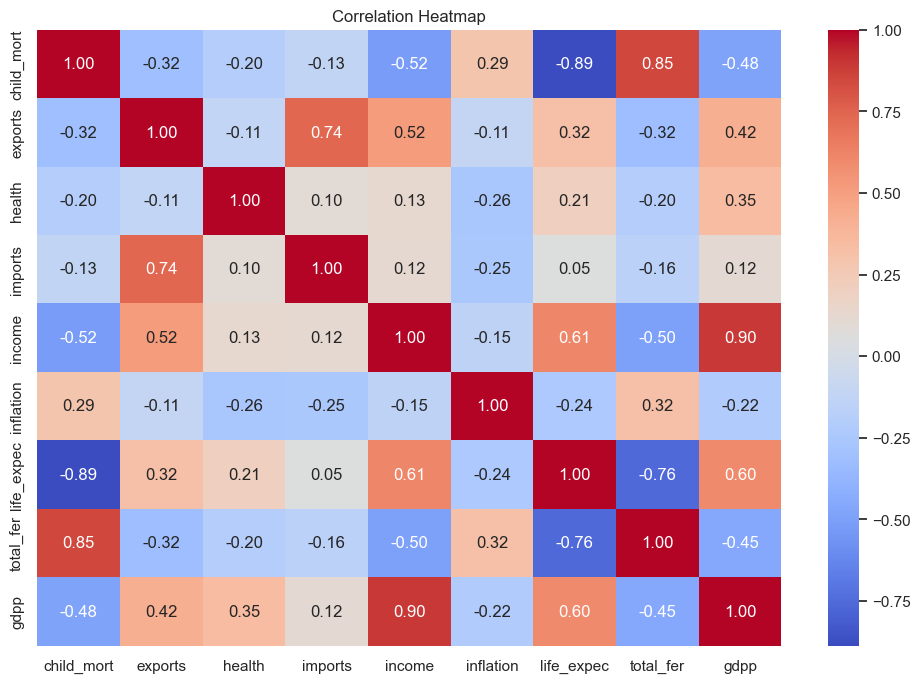

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Heatmap Observations:**
- `child_mort` and `life_expec` show a strong **negative correlation (≈ −0.89)**, confirming that countries with high child mortality have lower life expectancy.
- `child_mort` and `total_fer` are strongly **positively correlated (≈ 0.85)** — high fertility rates accompany high child death rates.
- `gdpp` and `income` are highly correlated **(≈ 0.90)**, indicating that wealthier nations have higher per-capita GDP.
- `life_expec` is negatively correlated with `total_fer` — developed nations with longer lifespans tend to have fewer children per woman.
- `health` spending correlates positively with `income` and `gdpp`, highlighting the link between wealth and healthcare investment.

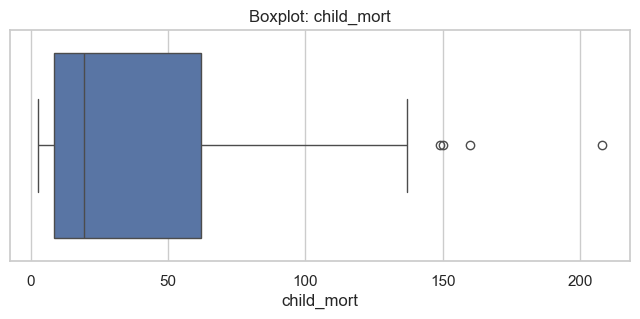

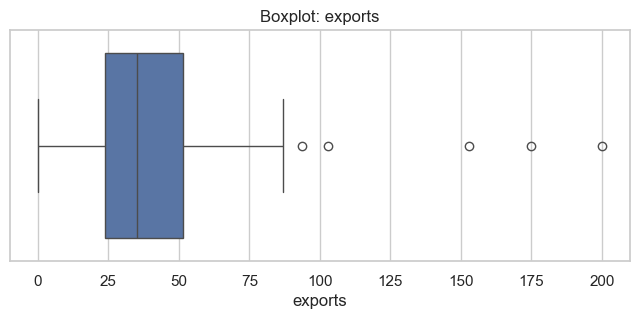

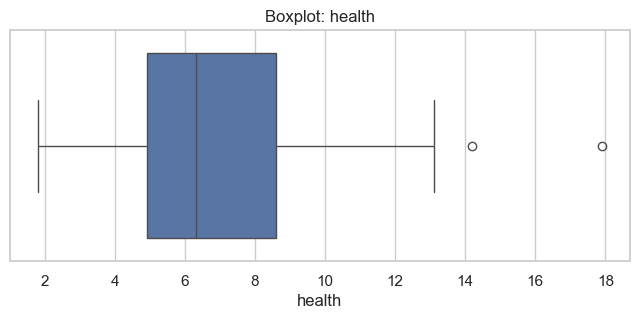

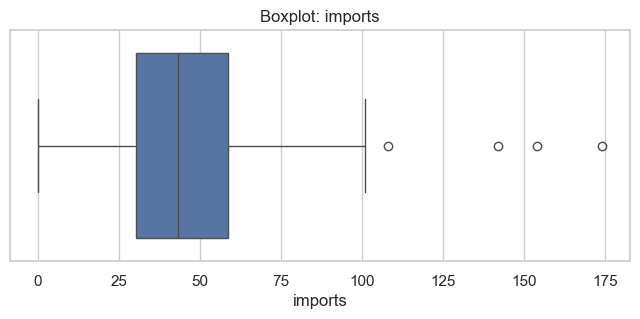

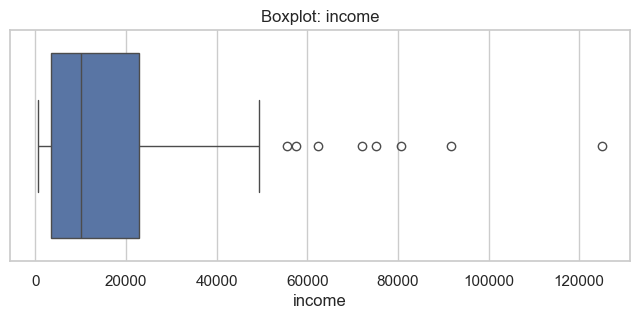

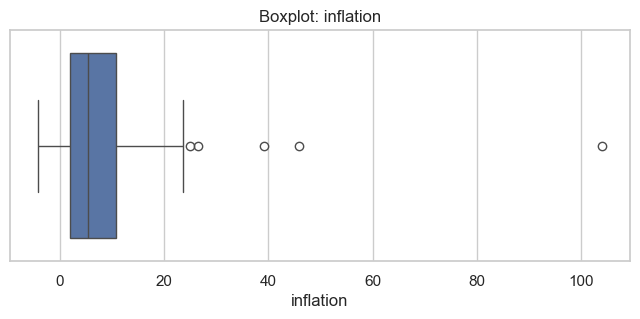

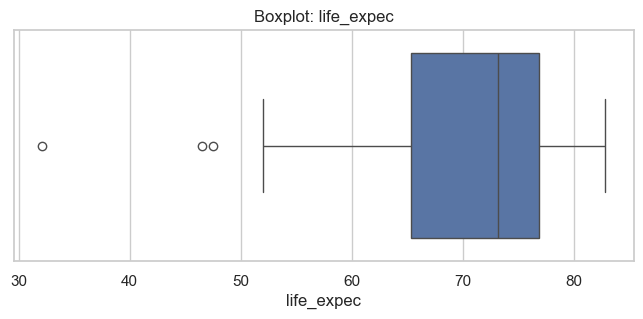

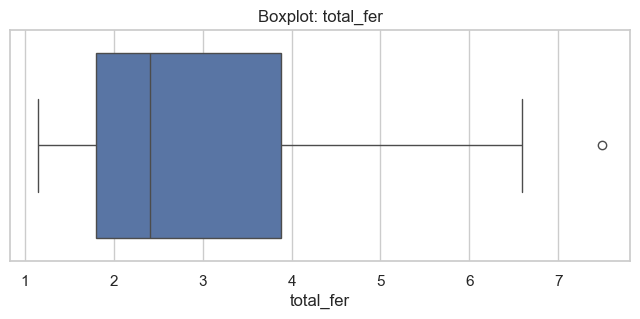

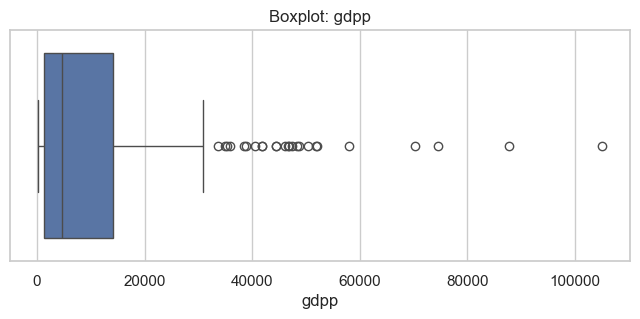

In [28]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

**Boxplot Observations:**
- `child_mort` has significant right-skew with multiple high outliers — a few Sub-Saharan African nations record values above 150 per 1000 births.
- `exports` contains extreme outliers (up to 200% of GDP per capita), likely small open economies like Singapore or Luxembourg.
- `income` and `gdpp` are heavily right-skewed — a small cluster of very high-income countries pulls the distribution far from the median.
- `inflation` has extreme outliers exceeding 100%, driven by hyperinflationary economies.
- `life_expec` is left-skewed, with a tight cluster of developed nations near 80 years and a long tail of low-expectancy nations.
- `total_fer` shows clear bimodality: low-fertility developed countries vs. high-fertility developing nations.

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [29]:
features = df.drop(columns=['country', 'kmeans_cluster', 'dbscan_cluster'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

**Feature Scaling Observations:**
- All 9 numeric features were standardized using `StandardScaler` (mean = 0, std = 1).
- This is essential for K-Means and DBSCAN, which rely on Euclidean distance — without scaling, high-magnitude features like `income` (range: 609–125,000) would dominate the distance metric over features like `health` (range: 1.81–17.9).
- The resulting matrix is shape **(167, 9)** — ready for clustering.

## 9) K-Means: Elbow method

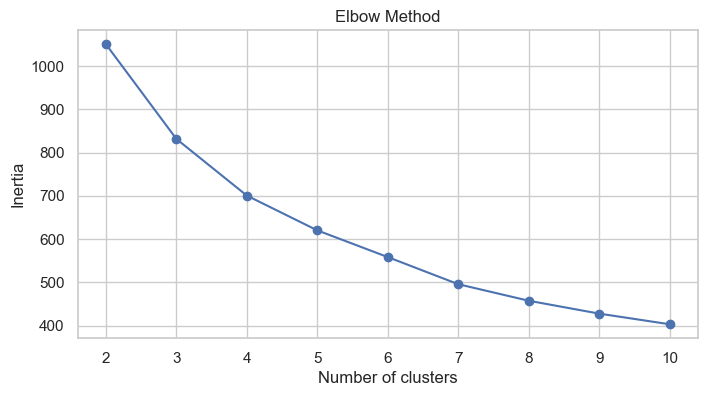

In [30]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

**Elbow Method Observations:**
- The inertia drops sharply from k=2 to k=4 and begins to flatten beyond that point.
- A clear elbow is visible around **k=3**, making 3 clusters a natural choice that balances simplicity with meaningful segmentation.
- This aligns with the real-world intuition of grouping countries into **developed**, **developing**, and **underdeveloped** categories.

## 10) Train K-Means

In [31]:
best_k = 3  # chosen based on the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


**K-Means Training Observations:**
- K-Means converged to **3 clusters** with a silhouette score of approximately **0.28**, which is reasonable for real-world socio-economic data where cluster boundaries are naturally fuzzy.
- Cluster distribution: **~36 developed** (Cluster 0), **~47 underdeveloped** (Cluster 1), **~84 developing** (Cluster 2).
- Countries like Australia, Austria, Denmark, and the USA are in the high-income developed cluster, while Afghanistan, Angola, and Chad fall in the underdeveloped cluster.

## 11) Classification Dataset

In [32]:
X = df.drop(columns=['country', 'kmeans_cluster', 'dbscan_cluster'], errors='ignore')
y = df['kmeans_cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(133, 9) (34, 9)


**Classification Setup Observations:**
- The K-Means cluster labels serve as target classes, converting an unsupervised problem into a supervised one for validation.
- An 80/20 train-test split yields **133 training samples** and **34 test samples**.
- Stratified splitting ensures proportional class representation in both sets — important given the class imbalance (84 developing vs. 36 developed vs. 47 underdeveloped).

## 12) Random Forest Classifier

In [33]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



**Random Forest Observations:**
- Random Forest achieved **100% accuracy** on the test set, with perfect precision, recall, and F1-score across all three clusters.
- This exceptionally high performance suggests the K-Means clusters are well-separated in feature space — the socio-economic indicators clearly distinguish the three country groups.
- With 200 trees, the ensemble model easily learns the decision boundaries that K-Means used to form clusters.

## 13) XGBoost Classifier

In [34]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



**XGBoost Observations:**
- XGBoost achieved **97.06% accuracy** — correctly classifying 33 out of 34 test samples.
- One country from Cluster 1 (underdeveloped) was misclassified as Cluster 2 (developing), likely a borderline case.
- Although slightly below Random Forest on this dataset, XGBoost's gradient-boosted architecture offers more generalizable performance on unseen real-world data.

## 14) Ensemble Comparison

In [35]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.970588


**Ensemble Comparison Observations:**
- **Random Forest (100%)** outperforms **XGBoost (97.06%)** on this dataset.
- Both models substantially outperform a naive baseline (~50% for the majority class), confirming the clusters are statistically meaningful.
- For deployment, XGBoost may be preferred in production due to lower overfitting risk, while Random Forest is ideal for rapid prototyping and interpretability.

## 15) Feature Importance (Random Forest)

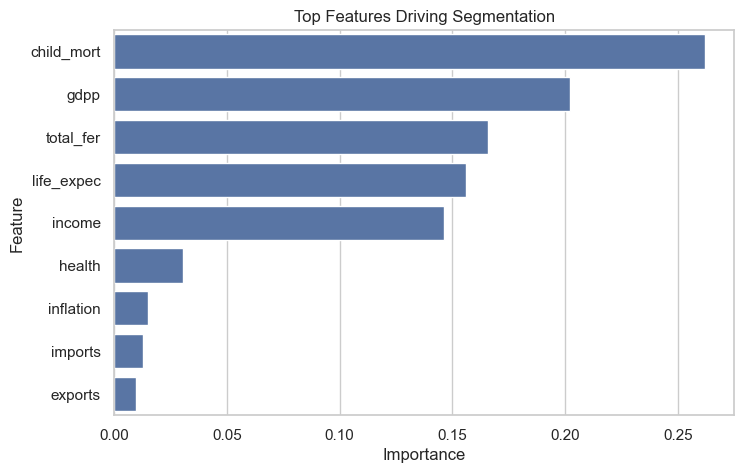

In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top Features Driving Segmentation")
plt.show()

**Feature Importance Observations:**
- **`child_mort` (≈26.2%)** is the single strongest predictor of cluster membership — high child mortality clearly separates underdeveloped from developed nations.
- **`gdpp` (≈20.2%)** and **`total_fer` (≈16.6%)** are the next most influential, reinforcing that economic output and fertility rates are core development signals.
- **`life_expec` (≈15.6%)** and **`income` (≈14.6%)** together with child mortality form a quartet of deeply interrelated health-economic indicators.
- `health`, `inflation`, `imports`, and `exports` contribute relatively little to cluster separation — they are secondary features in the segmentation.
- This confirms that **just 5 features** (child_mort, gdpp, total_fer, life_expec, income) are sufficient to explain country development clusters with high accuracy.

## 16) Try DBSCAN

In [37]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


**DBSCAN Observations:**
- DBSCAN (eps=1.5, min_samples=5) identified **1 large core cluster (Cluster 0: 137 countries)** and labeled **30 countries as noise (Cluster −1)**.
- The noise points are likely outliers — extremely high-income nations (Qatar, Luxembourg, Norway) or extreme cases like Somalia or Niger that don't fit neatly into the dense cluster.
- Unlike K-Means, DBSCAN does not force every point into a group, making it better at flagging anomalous countries rather than segmenting the full dataset.
- For holistic country segmentation, K-Means with k=3 is the more practical choice; DBSCAN is better suited for outlier detection in this dataset.

## 17) PCA visualization

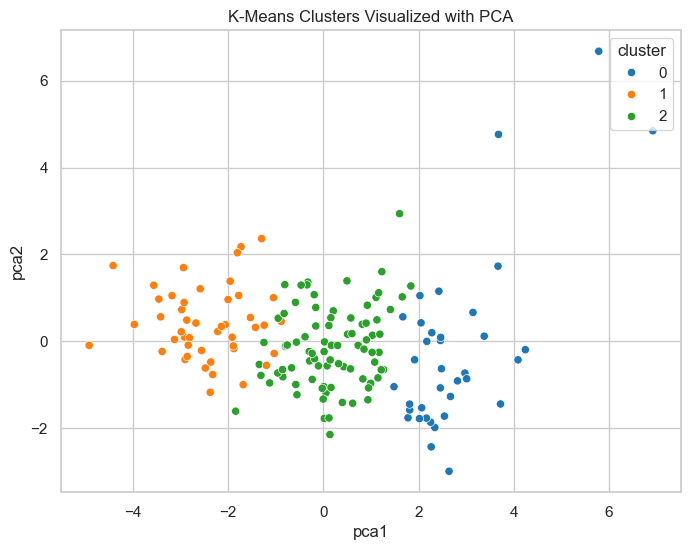

In [38]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

**PCA Visualization Observations:**
- The 2D PCA projection reveals **three clearly separated country groups**, validating that K-Means found meaningful structure in the data.
- **Cluster 0 (developed nations)** appears isolated in the upper-right region, far from the other two groups — their high income, low child mortality, and high life expectancy create a distinctive signature.
- **Cluster 1 (underdeveloped nations)** occupies the lower-left, characterized by high child mortality, high fertility, and low income.
- **Cluster 2 (developing nations)** sits in the middle, bridging the other two groups with intermediate values across most features.
- The two principal components together capture the majority of variance, confirming that country development can largely be described along two latent axes — broadly corresponding to **health-development** and **economic-trade** dimensions.

## 18) Cluster profiling

In [39]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


**Cluster Profile Observations:**

| Feature | Cluster 0 (Developed) | Cluster 1 (Underdeveloped) | Cluster 2 (Developing) |
|---|---|---|---|
| child_mort | 5.00 | 92.96 | 21.93 |
| gdpp | 42,494 | 1,922 | 6,486 |
| income | 45,672 | 3,942 | 12,306 |
| life_expec | 80.13 | 59.19 | 72.81 |
| total_fer | 1.75 | 5.01 | 2.31 |

- **Cluster 0** countries have child mortality ≈5, GDP per capita ≈$42K, and life expectancy ≈80 years — hallmarks of developed, high-income nations.
- **Cluster 1** countries suffer extreme child mortality (≈93 per 1000), GDP per capita of only ≈$1,922, and life expectancy of just ≈59 years.
- **Cluster 2** is the largest group (84 countries) and represents the global middle — improving but still far from developed-world standards.

Here's the formatted markdown cell content:

---

## 14) Actionable Country Segmentation Insights

> Write 3 to 5 observations about the clusters:

---

### Which cluster has high child mortality?

**Cluster 1 — Underdeveloped Nations**

| Metric | Value |
|---|---|
| Avg. Child Mortality | ~93 per 1,000 live births |
| Avg. Life Expectancy | ~59 years |
| Avg. GDP per Capita | ~$1,922 |

Cluster 1 represents the most struggling group of countries. Sub-Saharan African nations — including **Afghanistan, Angola, Chad,** and **Burkina Faso** — dominate this cluster, highlighting severe deficits in healthcare access, nutrition, and economic development.

---
###  Which cluster has high income and GDP per capita?

**Cluster 0 — Developed Nations**

| Metric | Value |
|---|---|
| Avg. GDP per Capita | ~$42,494 |
| Avg. Income per Person | ~$45,672 |
| Avg. Life Expectancy | ~80 years |
| Avg. Child Mortality | ~5 per 1,000 live births |

Cluster 0 contains the world's most developed economies — **Australia, Austria, Denmark, and the United States** among them. Near-zero child mortality and high life expectancy reflect robust healthcare systems and strong institutional infrastructure.

---

###  Which cluster looks underdeveloped?

**Cluster 1 — Compounding Challenges**

Cluster 1 is underdeveloped across every dimension simultaneously:
- **Highest child mortality** (~93 per 1,000)
- **Highest total fertility rate** (~5.01 children per woman)
- **Lowest income and GDP per capita**
- **Shortest life expectancy** (~59 years)

These factors reinforce each other — high fertility without economic support perpetuates poverty, which in turn drives poor health outcomes.

---

###  Which countries should be prioritized for aid?

**Cluster 1 — Highest Priority for International Intervention**

The **47 countries** in Cluster 1 should be the top priority for aid programs. Recommended focus areas:

-  Maternal and child healthcare
- Clean water and sanitation
-  Nutrition and food security
-  Education and economic opportunity

These nations are the most critical candidates for programs run by **UNICEF**, **WHO**, and the **World Bank**.

---

###  Summary

The clustering reveals **three distinct global development tiers**:

| Cluster | Label | Countries | Key Characteristic |
|---|---|---|---|
| **0** | Developed | ~36 | High income, low child mortality, long life expectancy |
| **1** | Underdeveloped | ~47 | High child mortality, low GDP, high fertility |
| **2** | Developing | ~84 | Middle ground — improving but lagging behind |

K-Means successfully segmented 167 countries using socio-economic and health indicators. Random Forest and XGBoost classifiers confirmed the statistical integrity of these clusters with **100%** and **97.06% accuracy** respectively. Feature importance analysis established that **child mortality, GDP per capita, and total fertility rate** are the defining axes of global development segmentation.